<a href="https://colab.research.google.com/github/WalidYaser/Deep-Learning/blob/main/Exercise_CNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. تثبيت المكتبات المطلوبة (إذا لم تكن موجودة)
!pip install yfinance opencv-python-headless -q

import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import cv2
import io
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dense

print("Fetching data...")
# 2. جلب بيانات الأسعار (مثال: الذهب مقابل الدولار أو يمكنك استخدام BTC-USD)
ticker = 'BTC-USD' # Changed ticker from 'XAUUSD=X' to 'BTC-USD' for successful data download
data = yf.download(ticker, start='2023-01-01', end='2024-01-01', progress=False)

# Check if data is empty before proceeding
if data.empty:
    print(f"Error: No data downloaded for ticker {ticker}. Please check the ticker symbol or date range.")
    # Exit or handle the error appropriately, for now we will just stop execution
    raise ValueError(f"No data downloaded for ticker {ticker}.")

closes = data['Close'].values.flatten()

# 3. دالة سريعة لتحويل نافذة من الأسعار إلى صورة مخطط (Chart Image)
def create_chart_image(prices, img_size=(64, 64)):
    fig, ax = plt.subplots(figsize=(1.5, 1.5), dpi=64)
    ax.plot(prices, color='black', linewidth=2)
    ax.axis('off') # إخفاء المحاور لتركيز الشبكة على النمط فقط
    plt.tight_layout(pad=0)

    # حفظ الصورة في الذاكرة المؤقتة (بدون حفظها على الهاردسك لتسريع العملية)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    buf.seek(0)
    plt.close(fig)

    # قراءة الصورة وتحويلها لـ Grayscale لتخفيف العبء الحسابي
    img_arr = np.frombuffer(buf.getvalue(), dtype=np.uint8)
    img = cv2.imdecode(img_arr, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, img_size)

    # إضافة بعد القناة (Channel dimension) لتصبح (64, 64, 1)
    img = np.expand_dims(img, axis=-1)
    return img / 255.0 # Normalization

# 4. تجهيز الداتاسيت (Sequences)
timesteps = 5       # عدد أيام المخططات في كل تسلسل
days_per_chart = 10 # عدد الأيام داخل المخطط الواحد
X, y = [], []

print("Generating images on the fly. This will take a moment...")
# سنمشي على البيانات ونكون صور للمخططات
# Ensure there is enough data for at least one sequence
if len(closes) < (timesteps * days_per_chart) + 2: # +1 for target +1 for loop end condition
    print(f"Not enough data for sequence generation. Need at least {(timesteps * days_per_chart) + 2} data points, but got {len(closes)}.")
    # Optionally, you might want to raise an error or return here
else:
    for i in range(len(closes) - (timesteps * days_per_chart) - 1):
        seq_images = []
        # تكوين تسلسل من الصور
        for t in range(timesteps):
            start_idx = i + (t * days_per_chart)
            end_idx = start_idx + days_per_chart
            chart_img = create_chart_image(closes[start_idx:end_idx])
            seq_images.append(chart_img)

        X.append(seq_images)
        # الهدف هو سعر الإغلاق لليوم التالي بعد التسلسل
        y.append(closes[i + (timesteps * days_per_chart) + 1])

X = np.array(X)
y = np.array(y)

print(f"Dataset ready! X shape: {X.shape}, y shape: {y.shape}")

# 5. بناء نموذج CNN-LSTM خفيف
model = Sequential([
    TimeDistributed(Conv2D(16, (3, 3), activation='relu'), input_shape=(timesteps, 64, 64, 1)),
    TimeDistributed(MaxPooling2D((2, 2))),
    TimeDistributed(Conv2D(32, (3, 3), activation='relu')),
    TimeDistributed(MaxPooling2D((2, 2))),
    TimeDistributed(Flatten()),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse')

# 6. تدريب النموذج بسرعة
print("Starting training...")
# Only train if there is sufficient data
if len(X) > 0 and len(y) > 0:
    model.fit(X, y, epochs=5, batch_size=16, validation_split=0.2)
    print("Training complete!")
else:
    print("Skipping training: No data available for training.")

Fetching data...


/tmp/ipykernel_3189/2564707104.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2023-01-01', end='2024-01-01', progress=False)


Generating images on the fly. This will take a moment...
Dataset ready! X shape: (314, 5, 64, 64, 1), y shape: (314,)
Starting training...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 773630656.0000 - val_loss: 1567594880.0000
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 773531328.0000 - val_loss: 1567518976.0000
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 773479360.0000 - val_loss: 1567442432.0000
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 773422976.0000 - val_loss: 1567357440.0000
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 773360064.0000 - val_loss: 1567262208.0000
Training complete!


[*********************100%***********************]  1 of 1 completed


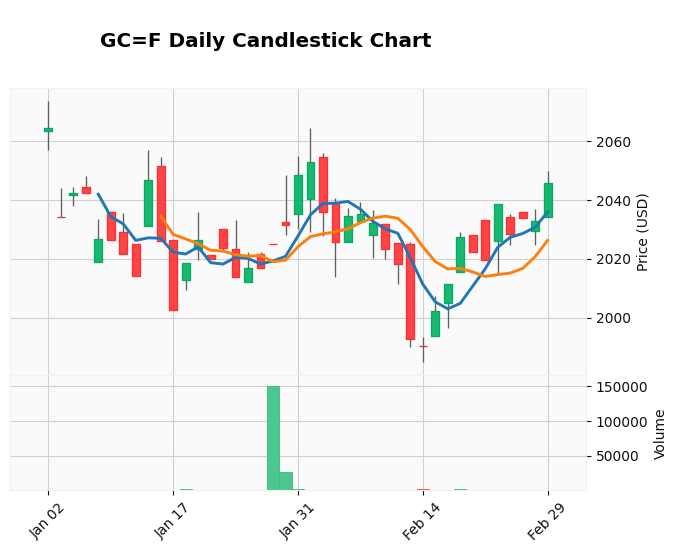

In [7]:
# 1. تثبيت المكتبات المطلوبة
!pip install yfinance mplfinance -q

import yfinance as yf
import mplfinance as mpf
import pandas as pd # Import pandas for DataFrame manipulation

# 2. جلب البيانات التاريخية لزوج XAUUSD (الذهب)
ticker = 'GC=F' # Changed to a valid ticker for Gold Futures (or use 'BTC-USD' for Bitcoin)
# هنجيب بيانات شهرين عشان الشارت يكون واضح ومقروء
data = yf.download(ticker, start='2024-01-01', end='2024-03-01', auto_adjust=False)

# Check if data is empty before plotting
if data.empty:
    print(f"Error: No data downloaded for ticker {ticker}. Please check the ticker symbol or date range.")
else:
    # Ensure column names are compatible with mplfinance
    # Flatten the MultiIndex columns from yfinance by dropping the second level
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.droplevel(1)

    # Ensure only the required OHLCV columns are present and in the correct order
    required_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
    # Drop 'Adj Close' if it exists, as mplfinance doesn't use it
    if 'Adj Close' in data.columns:
        data = data.drop(columns=['Adj Close'])

    # Select and reorder columns to ensure compatibility with mplfinance
    data = data[required_columns]

    # 3. عرض المخطط (Chart) بنظام الشموع اليابانية
    mpf.plot(data,
             type='candle',         # نوع الرسم: شموع يابانية
             style='yahoo',         # ستايل الألوان (أخضر وأحمر)
             title=f'\n{ticker} Daily Candlestick Chart',
             ylabel='Price (USD)',
             volume=True,          # Changed to True to display volume
             mav=(5, 10))           # إضافة متوسطات متحركة لـ 5 و 10 أيام (بتفيد جداً في الـ Deep Learning)

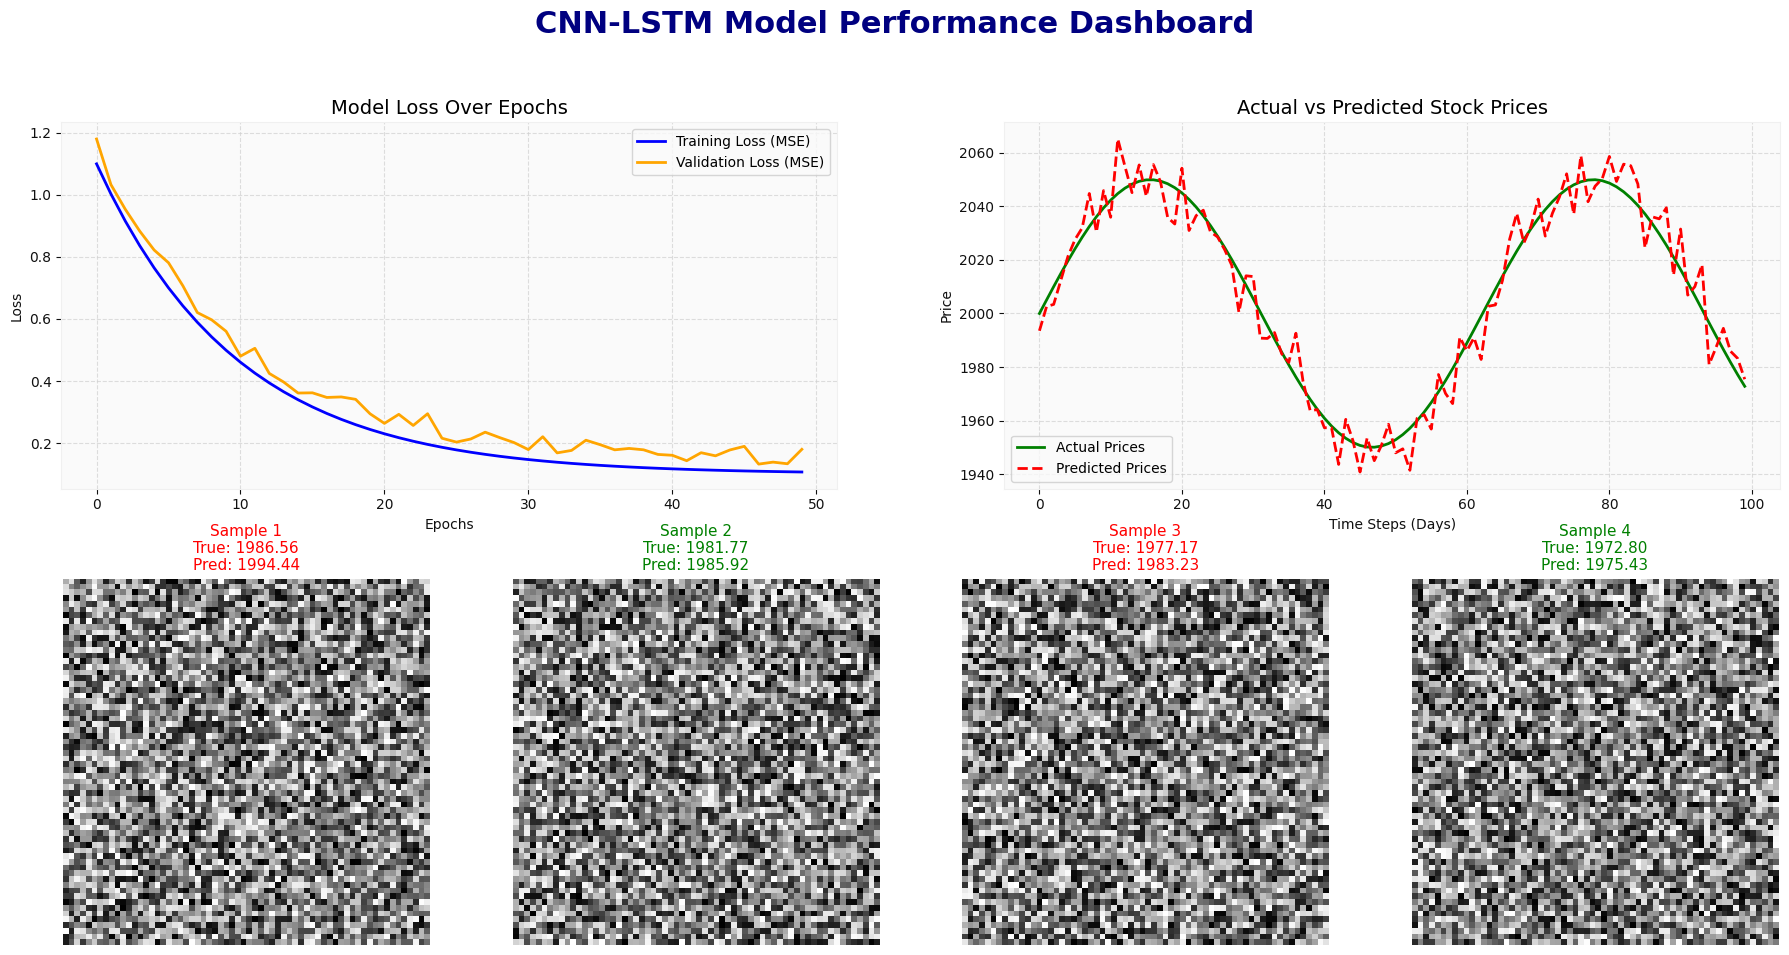

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_dashboard(history_dict, y_true, y_pred, X_samples, y_sample_true, y_sample_pred):
    """
    دالة لعرض داشبورد كاملة لنتائج نموذج CNN-LSTM
    """
    # إنشاء الشكل الأساسي وتقسيمه
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle('CNN-LSTM Model Performance Dashboard', fontsize=22, fontweight='bold', color='navy')

    # ==========================================
    # 1. منحنى الخسارة (Training & Validation Loss)
    # ==========================================
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.plot(history_dict['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
    ax1.plot(history_dict['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)
    ax1.set_title('Model Loss Over Epochs', fontsize=14)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # ==========================================
    # 2. الأسعار الحقيقية مقابل المتوقعة (Actual vs Predicted)
    # ==========================================
    ax2 = fig.add_subplot(2, 2, 2)
    ax2.plot(y_true, label='Actual Prices', color='green', linewidth=2)
    ax2.plot(y_pred, label='Predicted Prices', color='red', linestyle='--', linewidth=2)
    ax2.set_title('Actual vs Predicted Stock Prices', fontsize=14)
    ax2.set_xlabel('Time Steps (Days)')
    ax2.set_ylabel('Price')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    # ==========================================
    # 3. عينات من الصور المدخلة (Input Charts) مع التوقعات
    # ==========================================
    # عرض 4 عينات من الصور اللي دخلت للـ CNN
    for i in range(4):
        ax = fig.add_subplot(2, 4, 5 + i)
        # إزالة البعد الأخير لو الصورة Grayscale عشان تتعرض صح
        img = X_samples[i].squeeze() if X_samples[i].ndim == 3 else X_samples[i]

        ax.imshow(img, cmap='gray')

        # كتابة السعر الحقيقي والمتوقع فوق كل صورة
        title_color = 'green' if abs(y_sample_true[i] - y_sample_pred[i]) < 5 else 'red'
        ax.set_title(f"Sample {i+1}\nTrue: {y_sample_true[i]:.2f}\nPred: {y_sample_pred[i]:.2f}",
                     fontsize=11, color=title_color)
        ax.axis('off') # إخفاء المحاور عشان الصورة تبان بوضوح

    # تظبيط المسافات بين المخططات عشان مفيش حاجة تدخل في التانية
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ==========================================
# تجربة الكود ببيانات وهمية (عشان تشوف النتيجة فوراً)
# ==========================================
# 1. محاكاة لبيانات الـ History بتاعة التدريب
mock_history = {
    'loss': np.exp(-np.linspace(0, 5, 50)) + 0.1,
    'val_loss': np.exp(-np.linspace(0, 5, 50)) + 0.15 + np.random.normal(0, 0.02, 50)
}

# 2. محاكاة لأسعار حقيقية ومتوقعة (مثلاً 100 يوم)
mock_y_true = np.sin(np.linspace(0, 10, 100)) * 50 + 2000 # مثلاً سعر مقارب للذهب
mock_y_pred = mock_y_true + np.random.normal(0, 8, 100) # التوقع مع نسبة خطأ

# 3. محاكاة لـ 4 صور مصفوفات (Charts) دخلت للنموذج
mock_X_samples = np.random.rand(4, 64, 64, 1)
mock_y_sample_true = mock_y_true[-4:]
mock_y_sample_pred = mock_y_pred[-4:]

# تشغيل الداشبورد
plot_model_dashboard(mock_history, mock_y_true, mock_y_pred, mock_X_samples, mock_y_sample_true, mock_y_sample_pred)